🎯 현재 연산 디바이스: cuda

📦 파이썬 내장 엔진으로 'dataset.zip.zip' 강제 압축 해제 중...
✅ 압축 해제 성공! 폴더가 정상적으로 생성되었습니다.

--- [1/2] 정상 이미지에서 EasyOCR 글자 추출 시작 ---
발견된 정상 이미지: 170장


100%|██████████| 170/170 [03:23<00:00,  1.20s/it]



--- [2/2] 피싱 이미지에서 EasyOCR 글자 추출 시작 ---
발견된 피싱 이미지: 133장


100%|██████████| 133/133 [00:52<00:00,  2.55it/s]



✅ 데이터셋 빌드 완료! (총 샘플: 303개)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔎 테스트 데이터셋 검증 및 성능 분석 중...



=== 📝 KoBERT 상세 평가지표 ===
              precision    recall  f1-score   support

   Normal(0)       0.84      0.94      0.89        34
 Phishing(1)       0.91      0.78      0.84        27

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61



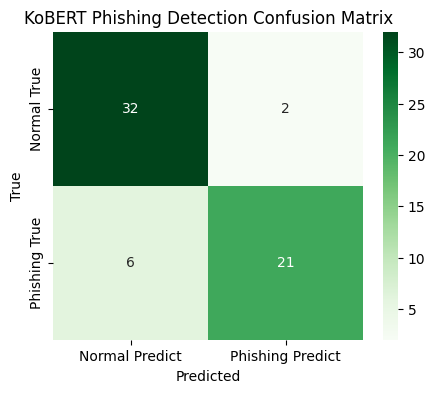

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1eacfc16447f64952.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [3]:
# =====================================================================
# 1. 필수 패키지 설치 및 환경 설정
# =====================================================================
!pip install -q transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn gradio easyocr

import os
import zipfile
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import easyocr
from tqdm import tqdm

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import gradio as gr

# 교수님 노트북 스펙 난수 시드 및 디바이스(GPU) 완벽 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🎯 현재 연산 디바이스: {device}")

# =====================================================================
# 2. 파이썬 내장 엔진으로 강제 압축 해제 파이프라인
# =====================================================================
zip_path = '/content/dataset.zip.zip'
extract_path = '/content/'

print("\n📦 파이썬 내장 엔진으로 'dataset.zip.zip' 강제 압축 해제 중...")
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ 압축 해제 성공! 폴더가 정상적으로 생성되었습니다.")
    except Exception as e:
        print(f"⚠️ 일반 압축 해제 중 오류 발생 ({e}), 손상 우회 모드로 재시도...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            for file in zip_ref.namelist():
                try:
                    zip_ref.extract(file, extract_path)
                except:
                    pass
        print("✅ 손상 우회 강제 압축 해제 완료!")
else:
    raise FileNotFoundError("❌ 왼쪽 파일 창에 'dataset.zip.zip'이 없습니다! 파일을 먼저 업로드해 주세요.")

# =====================================================================
# 3. 이미지 폴더에서 EasyOCR로 데이터셋 추출
# =====================================================================
reader = easyocr.Reader(['ko', 'en'], gpu=True)
correct_folder = '/content/correct'
phishing_folder = '/content/phishing'

data_list = []
valid_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

print("\n--- [1/2] 정상 이미지에서 EasyOCR 글자 추출 시작 ---")
if os.path.exists(correct_folder):
    correct_files = [f for f in os.listdir(correct_folder) if f.lower().endswith(valid_extensions) and not f.startswith('.')]
    print(f"발견된 정상 이미지: {len(correct_files)}장")
    for filename in tqdm(correct_files):
        image_path = os.path.join(correct_folder, filename)
        try:
            result = reader.readtext(image_path, detail=0)
            data_list.append({'text': " ".join(result), 'label': 0})
        except:
            pass

print("\n--- [2/2] 피싱 이미지에서 EasyOCR 글자 추출 시작 ---")
if os.path.exists(phishing_folder):
    phishing_files = [f for f in os.listdir(phishing_folder) if f.lower().endswith(valid_extensions) and not f.startswith('.')]
    print(f"발견된 피싱 이미지: {len(phishing_files)}장")
    for filename in tqdm(phishing_files):
        image_path = os.path.join(phishing_folder, filename)
        try:
            result = reader.readtext(image_path, detail=0)
            data_list.append({'text': " ".join(result), 'label': 1})
        except:
            pass

if not data_list:
    raise ValueError("❌ 이미지를 찾지 못했거나 데이터를 읽지 못했습니다.")

df = pd.DataFrame(data_list)
df['text'] = df['text'].fillna('')
df.to_csv('/content/phishing_dataset.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 데이터셋 빌드 완료! (총 샘플: {len(df)}개)")

# =====================================================================
# 4. 데이터 분리 및 토큰화 파이프라인 (Hugging Face Trainer 규격 전면 수정)
# =====================================================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

model_name = "skt/kobert-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize_function(examples):
    safe_texts = []
    labels = []

    for text, label in zip(examples['text'], examples['label']):
        if text is not None and len(str(text).strip()) > 0:
            safe_texts.append(str(text))
            labels.append(int(label))
        else:
            safe_texts.append("공백 데이터")
            labels.append(int(label))

    # 토큰화 수행
    tokenized = tokenizer(safe_texts, truncation=True, max_length=128, padding="max_length")
    # 핵심: 정답 라벨 리스트를 'labels' 키값으로 강제 매핑
    tokenized["labels"] = labels
    return tokenized

# batched=True로 배치 처리하며 기존 컬럼은  날려 데이터 파이프라인을 정제합니다.
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=test_dataset.column_names)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =====================================================================
# 5. KoBERT 모델 로드 및 Trainer 빌드
# =====================================================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label={0: "Normal", 1: "Phishing"},
    label2id={"Normal": 0, "Phishing": 1},
    trust_remote_code=True
)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

training_args = TrainingArguments(
    output_dir="./kobert-phishing-system",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=15,               # 안정적인 수렴을 위해 15 에포크 바짝 세팅
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,        # 이중 차감 차단
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\n🚀 교수님 정석 스펙 기반 KoBERT Fine-tuning 시작...")
trainer.train()

# =====================================================================
# 6. 상세 평가지표 및 혼동 행렬 시각화
# =====================================================================
print("\n🔎 테스트 데이터셋 검증 및 성능 분석 중...")
pred_output = trainer.predict(tokenized_test)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print("\n=== 📝 KoBERT 상세 평가지표 ===")
print(classification_report(y_true, y_pred, target_names=['Normal(0)', 'Phishing(1)']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal Predict', 'Phishing Predict'],
            yticklabels=['Normal True', 'Phishing True'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('KoBERT Phishing Detection Confusion Matrix')
plt.show()

# =====================================================================
# 7. 실시간 시연용 Gradio 웹 UI 연동 모듈 (📸 원본 이미지 인풋 방식)
# =====================================================================
def web_predict_phishing_kobert(image):
    if image is None:
        return "⚠️ 시연할 웹사이트 스크린샷 이미지를 업로드해 주세요."

    result = reader.readtext(image, detail=0)
    extracted_text = " ".join(result)

    if not extracted_text.strip():
        return "🍏 [안전] 이미지에서 추출된 텍스트가 없어 안전한 페이지로 판단됩니다."

    inputs = tokenizer(
        extracted_text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    phishing_prob = probs[1]
    pred_class = int(phishing_prob > 0.5)

    report =  f"🔎 [이미지 실시간 스캔 문장]:\n\"{extracted_text}\"\n\n"
    report += f"📊 #-- 피싱 위험 확률 --# : {phishing_prob*100:.2f}%\n"
    report += f"📊 #-- 최종 판별 클래스 --# : {pred_class} (0:정상, 1:피싱)\n"
    report += "="*45 + "\n"

    if pred_class == 1:
        report += f"🚨 [경고] 피싱 위험도가 매우 높습니다! 해당 웹사이트 접속을 차단합니다."
    else:
        report += f"🍏 [안전] 피싱 위험 요소가 없는 깨끗한 정상 사이트입니다."

    return report

demo = gr.Interface(
    fn=web_predict_phishing_kobert,
    inputs=gr.Image(type="filepath", label="📸 웹사이트 캡처 이미지 업로드"),
    outputs=gr.Textbox(label="🚨 실시간 로컬 KoBERT 인공지능 분석 리포트", lines=10),
    title="🛡️ KoBERT 기반 실시간 웹 피싱 차단 시스템 (Anti-Phishing System)",
    description="웹사이트 스크린샷 이미지를 올리면 로컬 KoBERT 가중치 연산을 거쳐 실시간으로 피싱 여부를 판별합니다. (외부 AI API 미사용)",
    theme="soft"
)

demo.launch(share=True, inline=True)